In [1]:
# === ノートブック共通の前処理 (llm_math パッケージの読み込み) ===
import sys
from pathlib import Path

# llm_math パッケージの候補パス
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# 親ディレクトリも候補に追加 (notebooks/ フォルダで実行する場合)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# llm_math の import を試行
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[注意] llm_math パッケージの読み込みエラー: {e}")
    print("  GitHub リポジトリを clone して colab_setup.sh を実行してください。")
# === 前処理ここまで ===


# Ch 04. 確率と統計

> **学習目標**
> - 分布 関数 , PMF/PDF/CDF
> - 複雑度(likelihood)
> - LLM " " 計算

## 4.1

**複雑度注意(Frequentist)**: = 複雑度. " 1/2" = 1/2 .

**(Bayesian)**: = 複雑度. データ .

LLM モデル. $w_t$ $P(w_t | w_{<t})$ 学習.


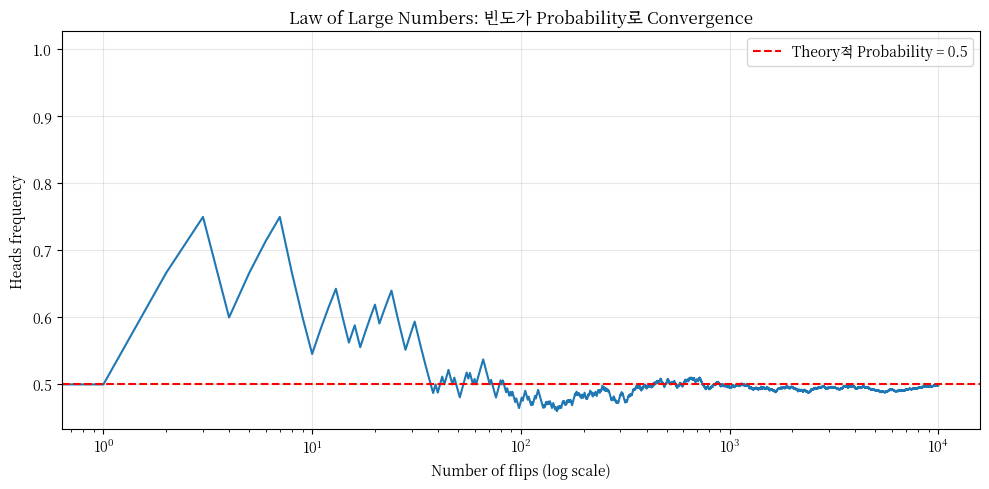

10000   複雑度: 0.4985 (TheoryValue 0.5)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

#   複雑度 
rng = np.random.default_rng(42)
n_flips = 10000
flips = rng.binomial(1, 0.5, n_flips)  # 1 = 
cumulative_freq = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_freq, linewidth=1.5)
plt.axhline(0.5, color='r', linestyle='--', label='Theory Probability = 0.5')
plt.xscale('log')
plt.xlabel('Number of flips (log scale)')
plt.ylabel('Heads frequency')
plt.title('Law of Large Numbers: 複雑度 Probability Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch04_law_of_large_numbers.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"10000   複雑度: {cumulative_freq[-1]:.4f} (TheoryValue 0.5)")


## 4.2 / 分布

### 分布 (PMF)
- **Bernoulli($p$)**: $P(X=1) = p$, $P(X=0) = 1-p$. .
- **Categorical($p_1, \ldots, p_k$)**: $P(X=i) = p_i$. , .

### 分布 (PDF)
- **分布 $\mathcal{N}(\mu, \sigma^2)$**:
$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

LLM 出力 Categorical 分布 — $V$ .


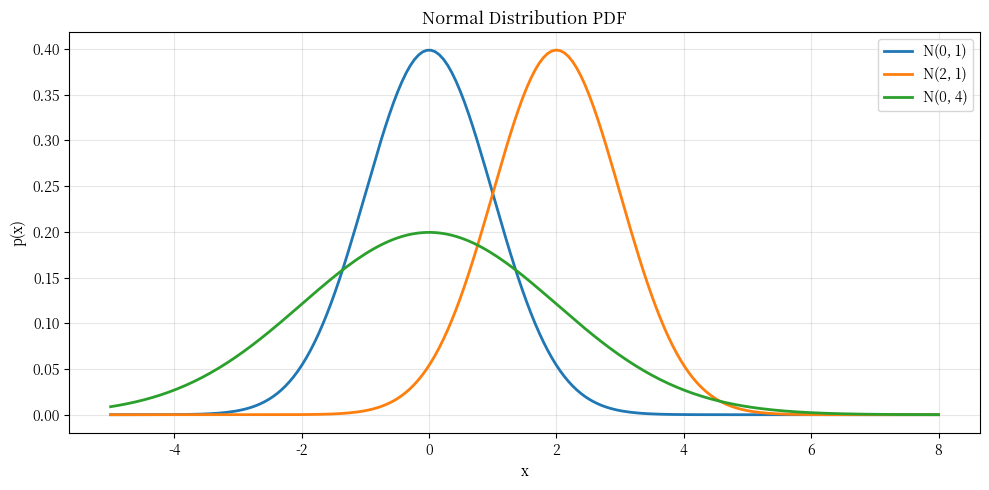

N(0,1) Sample 10000:
  Mean (Theory 0): 0.0063
  Variance (Theory 1): 0.9962
  Standard Deviation: 0.9981


In [3]:
# 分布 可視化
def normal_pdf(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu)**2) / (2 * sigma**2))

x = np.linspace(-5, 8, 200)
fig, ax = plt.subplots(figsize=(10, 5))
for mu, sigma, label in [(0, 1, 'N(0, 1)'), (2, 1, 'N(2, 1)'), (0, 2, 'N(0, 4)')]:
    ax.plot(x, normal_pdf(x, mu, sigma), linewidth=2, label=label)
ax.set_xlabel('x'); ax.set_ylabel('p(x)')
ax.set_title('Normal Distribution PDF')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch04_normal_dist.png', dpi=100, bbox_inches='tight')
plt.show()

#  
samples = np.random.default_rng(0).normal(0, 1, 10000)
print(f"N(0,1) Sample 10000:")
print(f"  Mean (Theory 0): {samples.mean():.4f}")
print(f"  Variance (Theory 1): {samples.var():.4f}")
print(f"  Standard Deviation: {samples.std():.4f}")


## 4.3

$$P(\theta | \mathcal{D}) = \frac{P(\mathcal{D} | \theta) P(\theta)}{P(\mathcal{D})}$$

- $P(\theta)$: (prior) — データ
- $P(\mathcal{D} | \theta)$: 複雑度 (likelihood) — $\theta$ データ
- $P(\theta | \mathcal{D})$: (posterior) — データ
- $P(\mathcal{D})$: (evidence) —

LLM 学習(MLE) 複雑度 special case.


In [4]:
#   :  
# P() = 0.01, P(|) = 0.99, P(|) = 0.05
P_D = 0.01
P_notD = 1 - P_D
P_pos_given_D = 0.99
P_pos_given_notD = 0.05

# P() = P(|)P() + P(|)P()
P_pos = P_pos_given_D * P_D + P_pos_given_notD * P_notD

# : P(|) = P(|)P() / P()
P_D_given_pos = P_pos_given_D * P_D / P_pos

print("  :  ")
print(f"  P() = {P_D}")
print(f"  P(|) = {P_pos_given_D} (複雑度)")
print(f"  P(|) = {P_pos_given_notD} ()")
print(f"  P() = {P_pos:.4f}")
print(f"  P(|) = {P_D_given_pos:.4f}")
print(f"\n   複雑度   Probability {P_D_given_pos*100:.1f}%!")
print(f"    :      .")


  :  
  P() = 0.01
  P(|) = 0.99 (複雑度)
  P(|) = 0.05 ()
  P() = 0.0594
  P(|) = 0.1667

   複雑度   Probability 16.7%!
    :      .


## 4.4 値, ,

- **値**: $\mathbb{E}[X] = \sum_x x P(x)$ —
- ****: $\mathrm{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2]$ — 複雑度
- ****: $\mathrm{Cov}(X, Y) = \mathbb{E}[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])]$
- ****: $\rho(X, Y) = \frac{\mathrm{Cov}(X, Y)}{\sigma_X \sigma_Y} \in [-1, 1]$


X: E[X] = -0.0045 (Theory 0), Var[X] = 0.9908 (Theory 1)
Y: E[Y] = 0.0054, Var[Y] = 0.7456
Cov(X, Y) = 0.7007
Corr(X, Y) = 0.8151 (Theory ≈ 0.81)


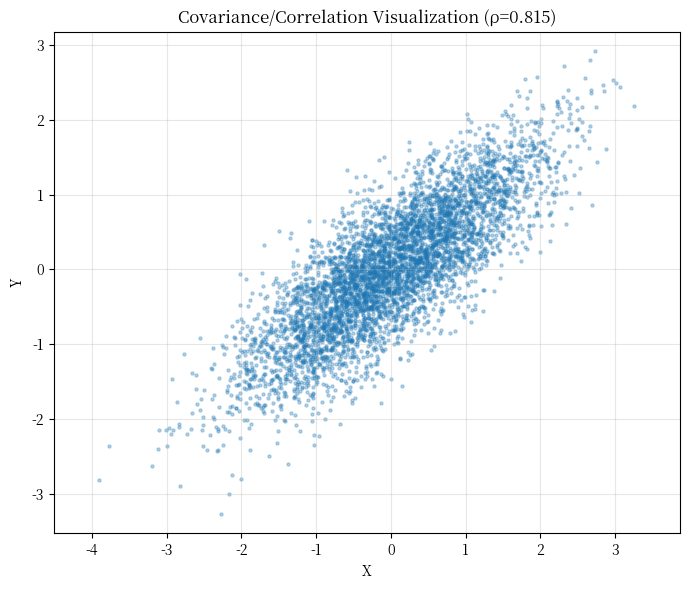

In [5]:
# 値  計算
rng = np.random.default_rng(0)

#  
n = 5000
X = rng.normal(0, 1, n)
Y = 0.7 * X + rng.normal(0, 0.5, n)  # X 

print(f"X: E[X] = {X.mean():.4f} (Theory 0), Var[X] = {X.var():.4f} (Theory 1)")
print(f"Y: E[Y] = {Y.mean():.4f}, Var[Y] = {Y.var():.4f}")
print(f"Cov(X, Y) = {np.cov(X, Y)[0, 1]:.4f}")
print(f"Corr(X, Y) = {np.corrcoef(X, Y)[0, 1]:.4f} (Theory ≈ 0.81)")

# 複雑度
plt.figure(figsize=(7, 6))
plt.scatter(X, Y, alpha=0.3, s=5)
plt.xlabel('X'); plt.ylabel('Y')
plt.title(f'Covariance/Correlation Visualization (ρ={np.corrcoef(X, Y)[0, 1]:.3f})')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig('../figures/ch04_correlation.png', dpi=100, bbox_inches='tight')
plt.show()


## 4.5 複雑度 (MLE)

 データ $\mathcal{D} = \{x_1, \ldots, x_N\}$ , $\theta$ 複雑度:
$$\mathcal{L}(\theta) = P(\mathcal{D} | \theta) = \prod_{i=1}^{N} P(x_i | \theta)$$

MLE: $\hat{\theta}_{\text{MLE}} = \arg\max_\theta \mathcal{L}(\theta)$

 (Log-Likelihood):
$$\ell(\theta) = \sum_{i=1}^{N} \log P(x_i | \theta)$$

LLM 学習 関数 $-\ell(\theta)$ — , ** 複雑度(NLL)** = .


値: mu=3.0, sigma=1.5
MLE:  mu_hat=2.9567, sigma_hat=1.4831


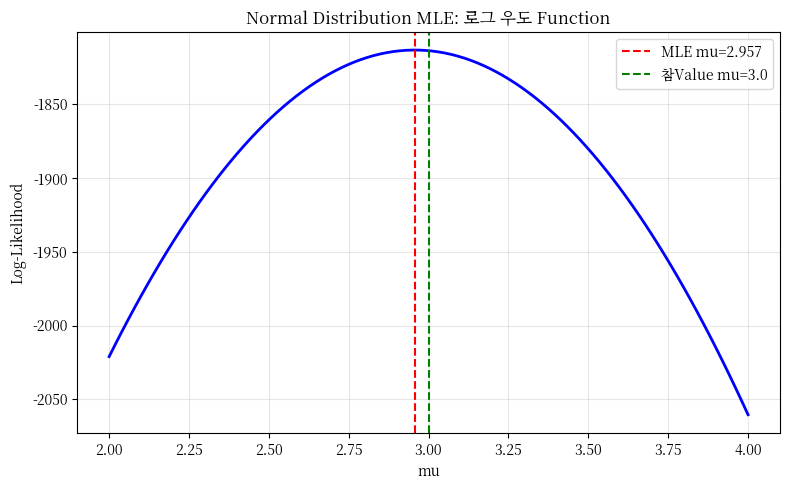

In [6]:
# MLE : 分布  
rng = np.random.default_rng(42)
true_mu, true_sigma = 3.0, 1.5
data = rng.normal(true_mu, true_sigma, 1000)

# 分布 MLE: mu_hat = mean, sigma_hat = sqrt(var)
mu_mle = data.mean()
sigma_mle = data.std()
print(f"値: mu={true_mu}, sigma={true_sigma}")
print(f"MLE:  mu_hat={mu_mle:.4f}, sigma_hat={sigma_mle:.4f}")

#  複雑度 関数 可視化 (mu)
def log_likelihood(mu, sigma, data):
    return np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((data - mu)**2) / (2 * sigma**2))

mus = np.linspace(2, 4, 100)
lls = [log_likelihood(m, sigma_mle, data) for m in mus]

plt.figure(figsize=(8, 5))
plt.plot(mus, lls, 'b-', linewidth=2)
plt.axvline(mu_mle, color='r', linestyle='--', label=f'MLE mu={mu_mle:.3f}')
plt.axvline(true_mu, color='g', linestyle='--', label=f'値 mu={true_mu}')
plt.xlabel('mu'); plt.ylabel('Log-Likelihood')
plt.title('Normal Distribution MLE:  複雑度 Function')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch04_mle.png', dpi=100, bbox_inches='tight')
plt.show()


## 4.6 複雑度

LLM $\mathbf{z} \in \mathbb{R}^{|V|}$ 分布 :

$$P(w_i) = \mathrm{softmax}(\mathbf{z})_i = \frac{\exp(z_i)}{\sum_j \exp(z_j)}$$

**複雑度(temperature) $\tau$** :
$$P_\tau(w_i) = \frac{\exp(z_i / \tau)}{\sum_j \exp(z_j / \tau)}$$

- $\tau \to 0$: 1 (greedy)
- $\tau = 1$:
- $\tau \to \infty$: 分布 


: [ 1.   2.   3.   0.5 -1. ]

tau= 0.5: [1.580e-02 1.166e-01 8.615e-01 5.800e-03 3.000e-04]
         Entropy = 0.4767
tau= 1.0: [0.0844 0.2294 0.6236 0.0512 0.0114]
         Entropy = 1.0441
tau= 2.0: [0.1535 0.2531 0.4173 0.1196 0.0565]
         Entropy = 1.4164
tau=10.0: [0.1962 0.2168 0.2397 0.1866 0.1606]
         Entropy = 1.6004


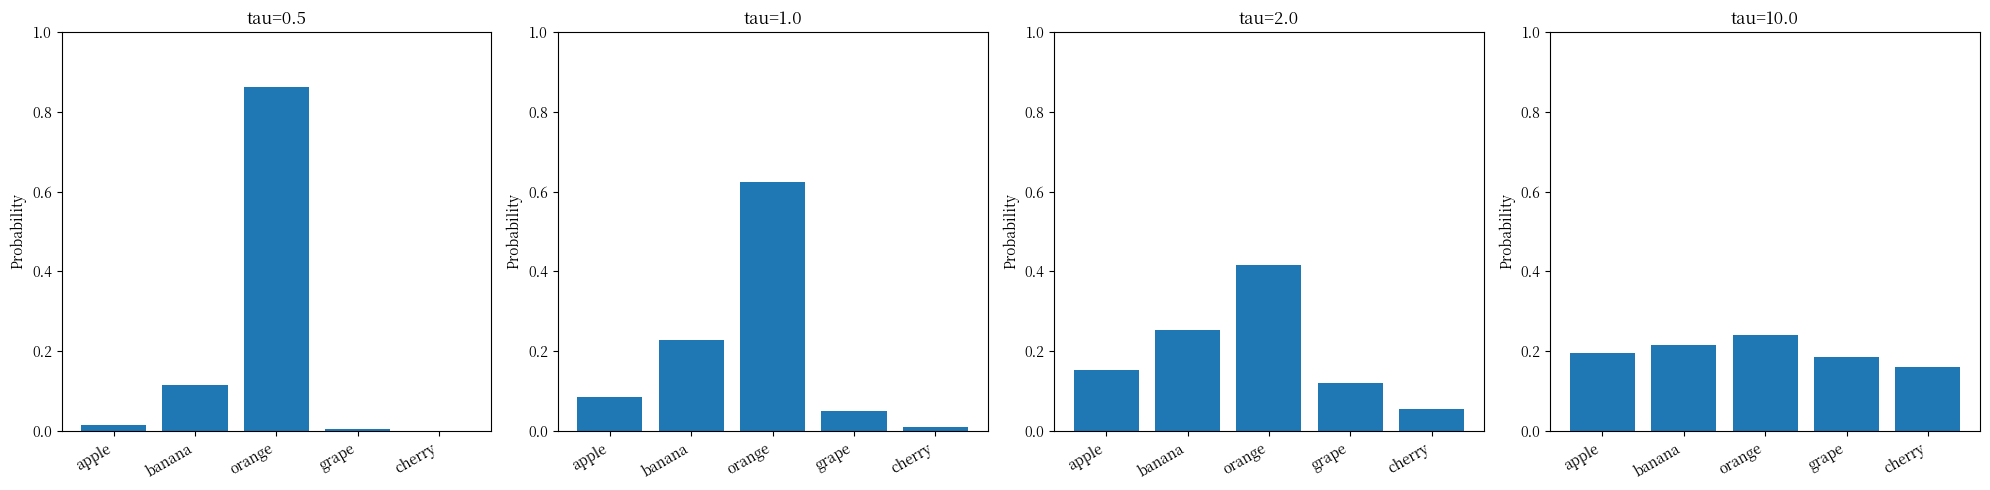


=> Temperature  Distribution (),  ().


In [7]:
#  複雑度 
def softmax(z, tau=1.0):
    z = np.asarray(z) / tau
    z = z - z.max()  # 
    e = np.exp(z)
    return e / e.sum()

#  
logits = np.array([1.0, 2.0, 3.0, 0.5, -1.0])
tokens = ['apple', 'banana', 'orange', 'grape', 'cherry']

print(f": {logits}")
print()
for tau in [0.5, 1.0, 2.0, 10.0]:
    p = softmax(logits, tau=tau)
    print(f"tau={tau:>4.1f}: {p.round(4)}")
    # Entropy
    entropy = -np.sum(p * np.log(p + 1e-12))
    print(f"         Entropy = {entropy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, tau in zip(axes, [0.5, 1.0, 2.0, 10.0]):
    p = softmax(logits, tau=tau)
    ax.bar(tokens, p, color='C0')
    ax.set_title(f'tau={tau}')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/ch04_softmax_temperature.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n=> Temperature  Distribution (),  ().")


## 4.7 要点

| | | |
|---|---|---|
| 値 | $\mathbb{E}[X] = \sum x P(x)$ | |
| | $\mathrm{Var}(X) = \mathbb{E}[(X-\mathbb{E}[X])^2]$ | 複雑度 |
| | $P(\theta\|\mathcal{D}) = \frac{P(\mathcal{D}\|\theta)P(\theta)}{P(\mathcal{D})}$ | |
| MLE | $\hat\theta = \arg\max P(\mathcal{D}\|\theta)$ | 複雑度 |
| | $\sigma(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$ | → |
| 複雑度 | $\sigma(z/\tau)$ | 分布 |

## 演習問題

1. 1000 , 複雑度 1/6 .
2. $\mathcal{N}(2, 4)$ 1000 , MLE $\mu, \sigma$ .
3. 計算: 30%, "free" 80%, 5%. "free" ?
4. 複雑度 $\tau=0.1, 1.0, 10$ 分布 計算, $\tau$ .
5. MLE MAP , MAP $P(\theta) = \mathcal{N}(0, \lambda)$ $L^2$ .

> 解答: `solutions/ch04_solutions.ipynb`
